# Setup

## Step 1.1 - Upload kaggle.json

In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


## Step 1.2 - Move it into place and lock permissions

In [2]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

## Step 1.3 - Install the CLI and verify

In [3]:
!pip install kaggle -q
!kaggle datasets list -s "cats and dogs"

ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
marquis03/cats-and-dogs                                    Cats and Dogs                                         10219362  2023-10-27 10:48:19.220000          17977        151                1  
mmoreaux/audio-cats-and-dogs                               Audio Cats and Dogs                                  101721956  2017-10-05 09:40:26.727000          19579        289        0.7647059  
mahmudulhaqueshawon/catcat                                 Cats and Dogs Classification                          65949527  2024-04-23 18:04:47.937000           3448        126            0.875  
samuelcortinhas/cats-and-

# Model Development & Experiment Tracking.




## Step 1.1 - Load the dataset

In [4]:
# Cell 1: Install & imports
!kaggle datasets download -d tongpython/cat-and-dog -p /content/data --unzip

#Inspect the folder structure
!find /content/data -maxdepth 3 -type d

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
100% 218M/218M [00:02<00:00, 77.1MB/s]

/content/data
/content/data/training_set
/content/data/training_set/training_set
/content/data/training_set/training_set/cats
/content/data/training_set/training_set/dogs
/content/data/test_set
/content/data/test_set/test_set
/content/data/test_set/test_set/cats
/content/data/test_set/test_set/dogs


In [5]:
# Cell 2: Count images per class
import os

for split in ['training_set/training_set', 'test_set/test_set']:
    for cls in ['cats', 'dogs']:
        path = f'/content/data/{split}/{cls}'
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{split}/{cls}: {count}")

training_set/training_set/cats: 4000
training_set/training_set/dogs: 4005
test_set/test_set/cats: 1011
test_set/test_set/dogs: 1012


In [6]:
# Cell 3: Build a dataframe of all image paths + labels
import pandas as pd
import os

records = []
for split in ['training_set/training_set', 'test_set/test_set']:
    for cls in ['cats', 'dogs']:
        folder = f'/content/data/{split}/{cls}'
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({'filepath': os.path.join(folder, fname), 'label': cls})

df = pd.DataFrame(records)
print(df.shape)
print(df['label'].value_counts())

(10028, 2)
label
dogs    5017
cats    5011
Name: count, dtype: int64


In [7]:
# Cell 4: 80/10/10 split, stratified by label
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

Train: (8022, 2) Val: (1003, 2) Test: (1003, 2)


## Step 1.2 - Class balance (already have this from train_df/val_df/test_df)



In [8]:
# Cell 5: Class balance (already have this from train_df/val_df/test_df)
import matplotlib.pyplot as plt

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(name, d['label'].value_counts().to_dict())

train {'dogs': 4013, 'cats': 4009}
val {'dogs': 502, 'cats': 501}
test {'dogs': 502, 'cats': 501}


## Step 1.3 - Sample images

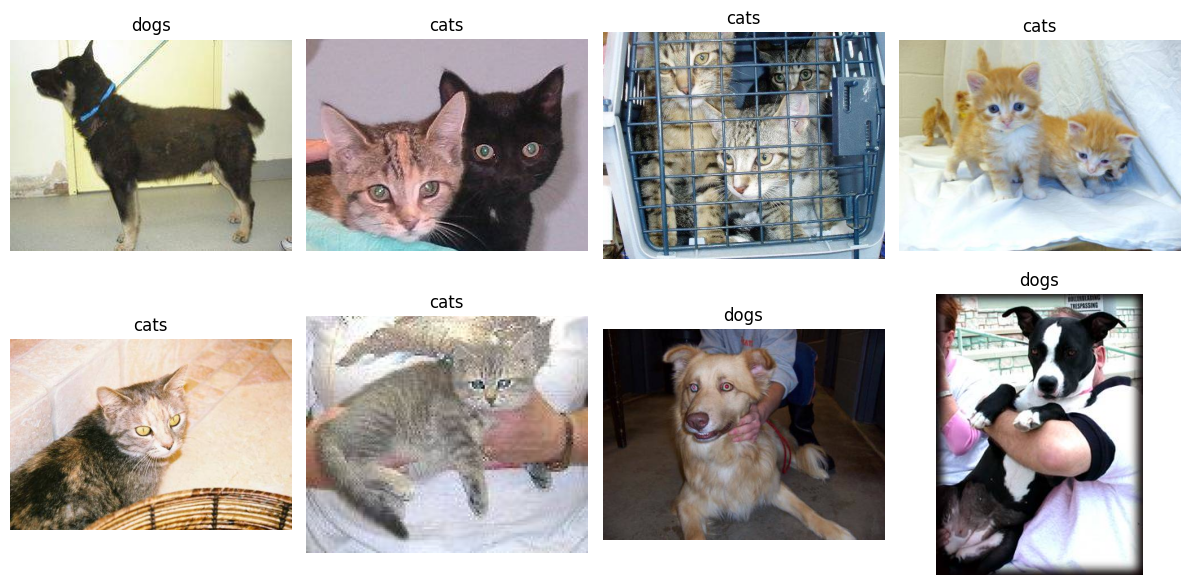

In [9]:
# Cell 6: Sample images
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample = train_df.sample(8, random_state=1).reset_index(drop=True)
for i, ax in enumerate(axes.flatten()):
    img = mpimg.imread(sample.loc[i, 'filepath'])
    ax.imshow(img)
    ax.set_title(sample.loc[i, 'label'])
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Step 1.4 - Check for corrupt/unreadable images across the full set

In [10]:
# Cell 7: Check for corrupt/unreadable images across the full set
from PIL import Image

bad_files = []
for fp in df['filepath']:
    try:
        img = Image.open(fp)
        img.verify()
    except Exception:
        bad_files.append(fp)

print(f"Corrupt/unreadable files: {len(bad_files)}")

Corrupt/unreadable files: 0


## Step 1.5 - Build the tf.data pipeline

In [11]:
# Cell 8: Build tf.data datasets from the dataframes
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

def make_dataset(df, training=False):
    labels = (df['label'] == 'dogs').astype(int).values  # cats=0, dogs=1
    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE)

    if training:
        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1),
        ])
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Datasets built")

Datasets built


## Step 1.6 - Define a simple CNN architecture

In [12]:
# Cell 9: Build the CNN
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # binary: cat=0, dog=1
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


* 3 conv blocks (32→64→128 filters) is a standard "baseline CNN" shape — enough to learn real features without being unnecessarily deep for a binary classification task with only 2 classes.
* Dropout(0.5) before the final layer helps control overfitting, which matters more here than in tabular data given how easily CNNs memorize image datasets this size.

* Sigmoid + binary_crossentropy since this is binary classification with a single output neuron — matches the cats=0/dogs=1 encoding from Step 1.5.



## Step 1.7 - GPU check

In [13]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1.8 - Train the CNN

In [14]:
# Cell 10: Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 101s 361ms/step - accuracy: 0.5552 - loss: 0.7041 - val_accuracy: 0.6251 - val_loss: 0.6324
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 338ms/step - accuracy: 0.6310 - loss: 0.6475 - val_accuracy: 0.6939 - val_loss: 0.5988
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 85s 332ms/step - accuracy: 0.6688 - loss: 0.6156 - val_accuracy: 0.6959 - val_loss: 0.5672
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 333ms/step - accuracy: 0.6931 - loss: 0.5974 - val_accuracy: 0.6869 - val_loss: 0.5878
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 330ms/step - accuracy: 0.7173 - loss: 0.5617 - val_accuracy: 0.7308 - val_loss: 0.5495
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 85s 331ms/step - accuracy: 0.7284 - loss: 0.5455 - val_accuracy: 0.7358 - val_loss: 0.5212
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 330ms/step - accuracy: 0.7422 - loss: 0.5215 - val_accuracy: 0.7607 - val_loss: 0.4776
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 329ms/step - accuracy: 0.7593 - loss

## Step 1.9 - Evaluate on the held-out test set

In [15]:
# Cell 11: Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.7767 - loss: 0.4571
Test Accuracy: 0.7767
Test Loss: 0.4571


In [16]:
# Cell 12: Generate predictions for confusion matrix / metrics
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_true = []
y_pred_proba = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_proba.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['cat', 'dog']))
print("ROC-AUC:", roc_auc_score(y_true, y_pred_proba))

              precision    recall  f1-score   support

         cat       0.85      0.68      0.75       501
         dog       0.73      0.88      0.80       502

    accuracy                           0.78      1003
   macro avg       0.79      0.78      0.77      1003
weighted avg       0.79      0.78      0.77      1003

ROC-AUC: 0.8840605641307027


## Step 1.10 - Save the model and generate a confusion matrix plot

In [17]:
# Cell 13: Save model in .h5 format
model.save('cats_dogs_cnn.h5')
print("Model saved")

Model saved


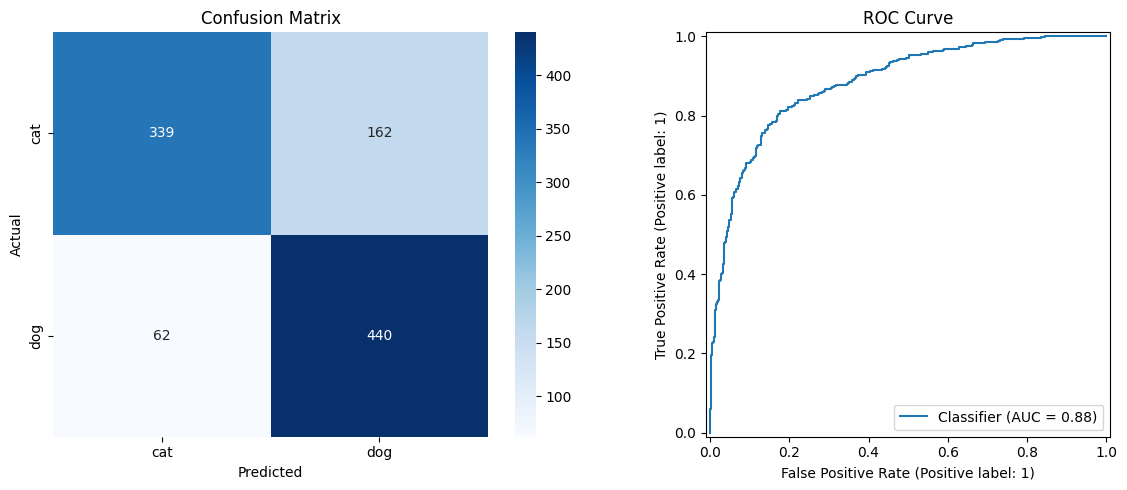

In [18]:
# Cell 14: Confusion matrix plot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['cat', 'dog'], yticklabels=['cat', 'dog'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_true, y_pred_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=150)
plt.show()

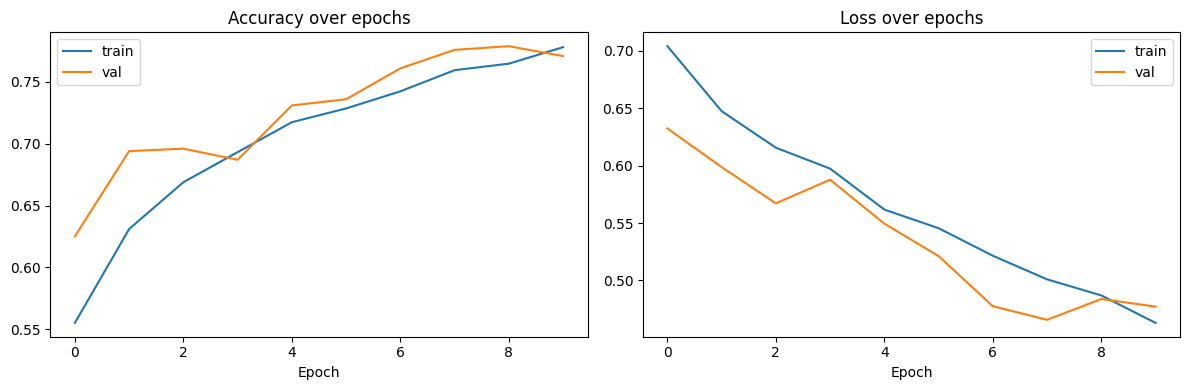

In [19]:
# Cell 14: Loss/accuracy curves from training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', dpi=150)
plt.show()

## Step 1.11 - Log everything to MLflow

In [20]:
# Cell 15: Install and set up MLflow
!pip install mlflow -q

import mlflow

mlflow.set_experiment("cats-dogs-classification")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

2026/08/27 18:43:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/27 18:43:11 INFO mlflow.store.db.utils: Updating database tables
2026/08/27 18:43:14 INFO mlflow.tracking.fluent: Experiment with name 'cats-dogs-classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1787856194112, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787856194112, lifecycle_stage='active', name='cats-dogs-classification', tags={}, trace_location=None, workspace='default'>

In [21]:
# Cell 16: Log the run
with mlflow.start_run(run_name="baseline_cnn"):
    # Params
    mlflow.log_param("model_type", "CNN")
    mlflow.log_param("input_shape", "224x224x3")
    mlflow.log_param("conv_layers", 3)
    mlflow.log_param("filters", "32,64,128")
    mlflow.log_param("dropout", 0.5)
    mlflow.log_param("optimizer", "adam")
    mlflow.log_param("epochs", 10)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("augmentation", "flip,rotation,zoom")

    # Metrics - final epoch training metrics
    mlflow.log_metric("train_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("train_loss", history.history['loss'][-1])
    mlflow.log_metric("val_accuracy", history.history['val_accuracy'][-1])
    mlflow.log_metric("val_loss", history.history['val_loss'][-1])

    # Metrics - test set
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_roc_auc", roc_auc_score(y_true, y_pred_proba))

    # Log accuracy per epoch as a series (nice for MLflow's built-in charts)
    for epoch, (acc, val_acc) in enumerate(zip(history.history['accuracy'], history.history['val_accuracy'])):
        mlflow.log_metric("epoch_accuracy", acc, step=epoch)
        mlflow.log_metric("epoch_val_accuracy", val_acc, step=epoch)

    # Artifacts
    mlflow.log_artifact('confusion_matrix_roc.png')
    mlflow.log_artifact('loss_accuracy_curves.png')
    mlflow.log_artifact('sample_images.png')

    # Model itself
    mlflow.log_artifact('cats_dogs_cnn.h5')

    mlflow.set_tag("baseline_model", "true")

print("Run logged to MLflow")

Run logged to MLflow


In [22]:
# Cell 16: Quick check via search_runs (no tunnel needed)
import mlflow

runs_df = mlflow.search_runs(experiment_names=["cats-dogs-classification"])
display(runs_df[['tags.mlflow.runName', 'metrics.test_accuracy', 'metrics.test_roc_auc',
                  'metrics.val_accuracy', 'params.epochs']])

,tags.mlflow.runName,metrics.test_accuracy,metrics.test_roc_auc,metrics.val_accuracy,params.epochs
0,baseline_cnn,0.77667,0.884061,0.770688,10
